# PCA + $k$-Means Pipeline

---

## Why Combine PCA and $k$-Means?

### The Curse of Dimensionality

In high-dimensional space, **all distances tend toward the same value**. As $d \to \infty$, the ratio of the maximum to minimum pairwise distance approaches 1, making nearest-neighbor assignments meaningless. $k$-Means relies entirely on Euclidean distances, so it degrades rapidly in high dimensions.

Additionally, many real datasets have **correlated features**: the gym dataset has 15 features but the intrinsic dimensionality may be only 3-5 (body metrics are correlated, session metrics are correlated). Running $k$-Means in the full 15D space gives equal weight to noisy directions.

### How PCA Fixes This

PCA **denoises and compresses** before clustering:
1. Removes correlated features by rotating to the direction of maximum variance
2. Drops low-variance components that are mostly noise
3. Makes Euclidean distances in the reduced space more meaningful
4. Reduces computation from $O(Nkd)$ to $O(Nkk')$ where $k' \ll d$

---

## Pipeline Steps

1. **StandardScale** the data so all features have unit variance
2. **PCA**: select $k'$ components explaining $\geq 90\%$ variance
3. **$k$-Means**: apply to the PCA-reduced representation
4. **Evaluate**: compare inertia and silhouette score vs raw-feature clustering
5. **Visualize**: project to 2D (first 2 PCA components) for interpretation

---

## Advantages of the PCA + $k$-Means Combo

| Property | Raw $k$-Means | PCA + $k$-Means |
|---|---|---|
| Distance quality | Noisy in high-$d$ | Meaningful (denoised) |
| Speed | $O(Nkd)$ | $O(Nkk')$, $k' \ll d$ |
| Handles correlated features | No | Yes (PCA removes redundancy) |
| Visualization | Requires separate PCA step | Natural (use PCA components) |
| Overfitting to noise | Yes | Reduced |

---

## When to Use This Pipeline

- Dataset has $d > 10$ features and you suspect correlations
- Raw clustering gives unstable or poorly-separated clusters
- You want to visualize clusters in 2D without a separate reduction step
- Downstream interpretation benefits from a small set of components

**Caution:** do not use when features are genuinely independent and all informative. PCA may discard useful signal if variance is spread across many independent features.

---

**Dataset:** Gym Members Exercise Tracking (`gym_members_exercise_tracking.csv`)  
**Task:** Cluster gym members by exercise behavior using the combined PCA + $k$-Means pipeline.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme()

from rice_ml.unsupervised_learning import PCA, KMeans
from rice_ml.preprocess import StandardScaler

In [2]:
try:
    df = pd.read_csv('../../../data/gym_members_exercise_tracking.csv')
    num_cols = df.select_dtypes(include=np.number).columns.tolist()
    X = df[num_cols].dropna().values.astype(float)
    print(f'Loaded gym dataset: {X.shape}')
except FileNotFoundError:
    from sklearn.datasets import load_iris
    iris = load_iris()
    X = iris.data
    print('CSV not found. using iris dataset')

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print(f'Shape: {X_scaled.shape}')

Loaded gym dataset: (973, 13)
Shape: (973, 13)


## Dataset Description

**gym_members_exercise_tracking.csv** contains **973 gym members** with **15 features**:
[Download from Kaggle](https://www.kaggle.com/datasets/valakhorasani/gym-members-exercise-dataset)


- **Demographic:** Age, Gender
- **Body metrics:** Weight (kg), Height (m), BMI, Body Fat Percentage
- **Session data:** Session Duration (hours), Calories Burned, Workout Type
- **Performance:** Max BPM, Avg BPM, Resting BPM
- **Habits:** Water Intake (liters), Workout Frequency (days/week), Experience Level

Many features are correlated (e.g. BMI with Weight, Calories Burned with Session Duration). PCA will reduce this to a compact representation before clustering.

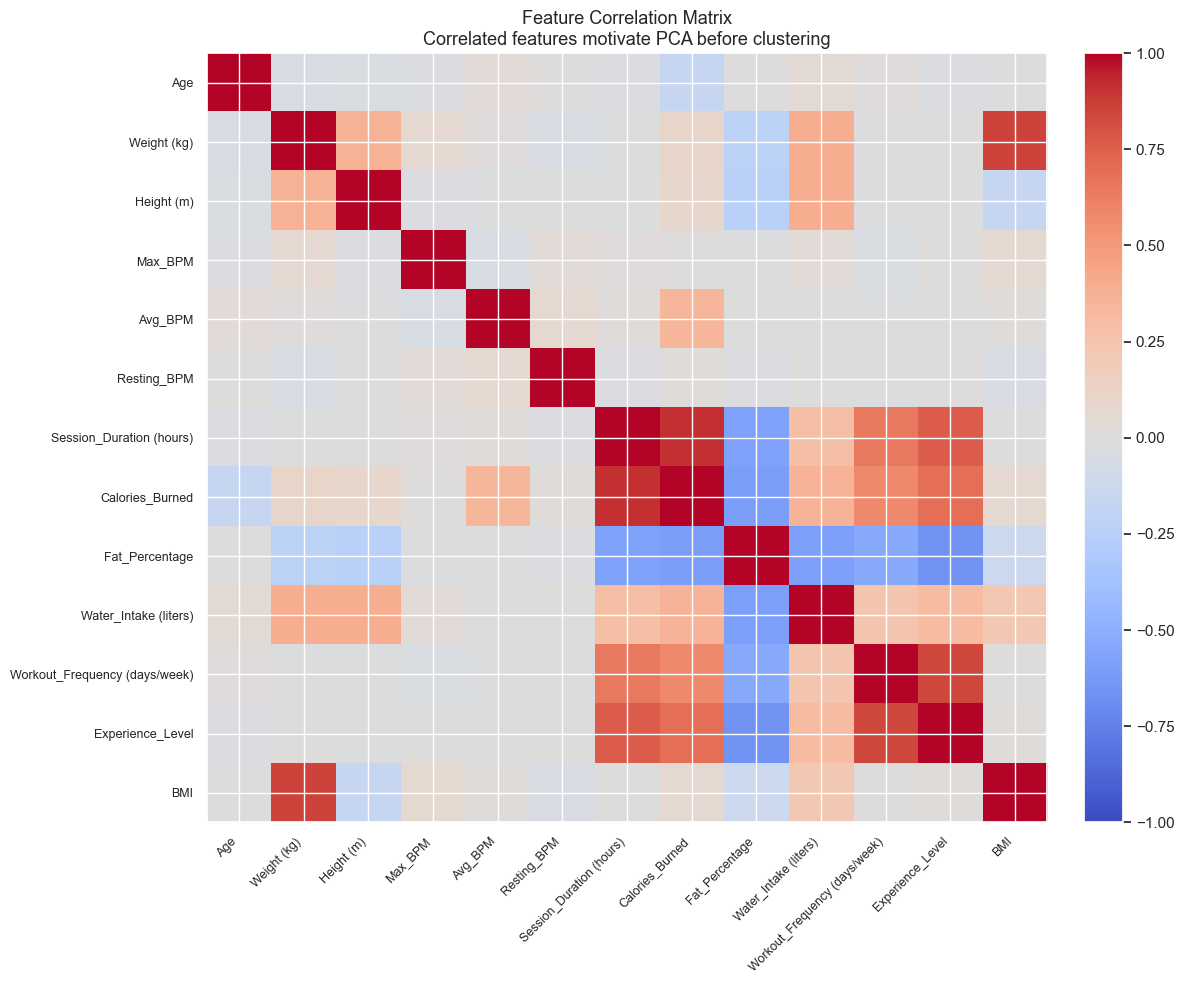

In [3]:
# --- EDA: Correlation heatmap (same as pca.ipynb, motivates using PCA first) ---
try:
    num_df = df[num_cols].dropna()
    corr = num_df.corr()
    fig, ax = plt.subplots(figsize=(12, 10))
    im = ax.imshow(corr.values, cmap='coolwarm', vmin=-1, vmax=1, aspect='auto')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    ax.set_xticks(range(len(num_cols)))
    ax.set_xticklabels(num_cols, rotation=45, ha='right', fontsize=9)
    ax.set_yticks(range(len(num_cols)))
    ax.set_yticklabels(num_cols, fontsize=9)
    ax.set_title('Feature Correlation Matrix\nCorrelated features motivate PCA before clustering', fontsize=13)
    plt.tight_layout()
    plt.show()
except NameError:
    corr_mat = np.corrcoef(X_scaled.T)
    fig, ax = plt.subplots(figsize=(8, 6))
    im = ax.imshow(corr_mat, cmap='coolwarm', vmin=-1, vmax=1)
    plt.colorbar(im, ax=ax)
    ax.set_title('Feature Correlation Matrix', fontsize=13)
    plt.tight_layout()
    plt.show()

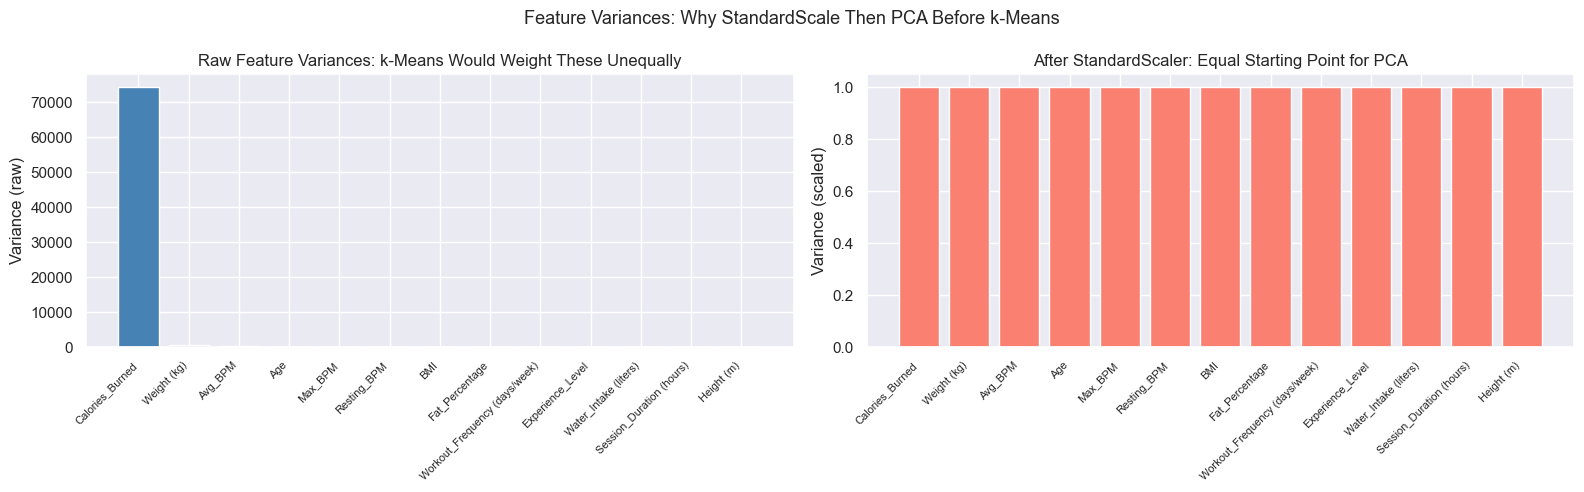

In [4]:
# --- EDA: Feature variance bar chart ---
raw_variances = X.var(axis=0)
sorted_idx = np.argsort(raw_variances)[::-1]

try:
    feat_names = [num_cols[i] for i in sorted_idx]
except NameError:
    feat_names = [f'Feature {i}' for i in sorted_idx]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
axes[0].bar(range(len(raw_variances)), raw_variances[sorted_idx], color='steelblue')
axes[0].set_xticks(range(len(feat_names)))
axes[0].set_xticklabels(feat_names, rotation=45, ha='right', fontsize=8)
axes[0].set_ylabel('Variance (raw)', fontsize=12)
axes[0].set_title('Raw Feature Variances: k-Means Would Weight These Unequally', fontsize=12)

scaled_variances = X_scaled.var(axis=0)
axes[1].bar(range(len(scaled_variances)), np.sort(scaled_variances)[::-1], color='salmon')
axes[1].set_xticks(range(len(feat_names)))
axes[1].set_xticklabels(feat_names, rotation=45, ha='right', fontsize=8)
axes[1].set_ylabel('Variance (scaled)', fontsize=12)
axes[1].set_title('After StandardScaler: Equal Starting Point for PCA', fontsize=12)

plt.suptitle('Feature Variances: Why StandardScale Then PCA Before k-Means', fontsize=13)
plt.tight_layout()
plt.show()

## Step 1: PCA - Choose Number of Components

Components for 90% variance: 8


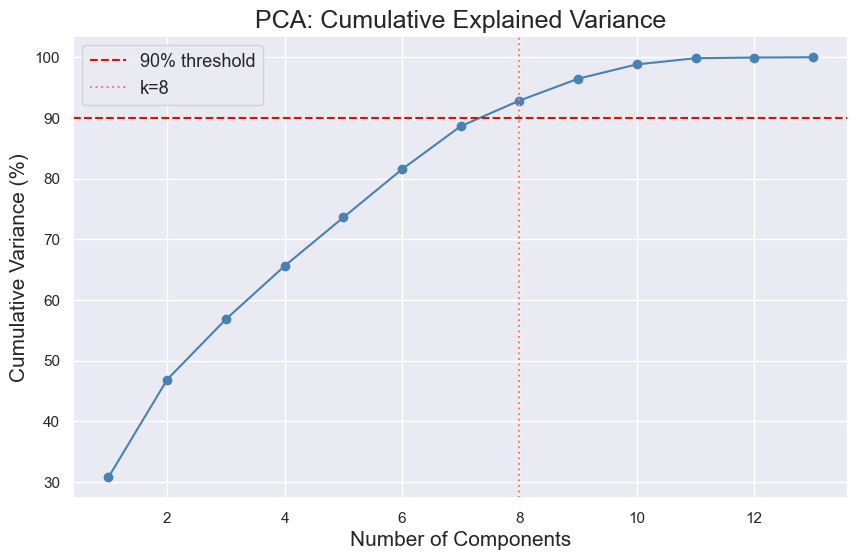

In [5]:
pca_full = PCA(n_components=X_scaled.shape[1])
pca_full.fit(X_scaled)
cumulative = np.cumsum(pca_full.explained_variance_ratio_)

n_components = int(np.argmax(cumulative >= 0.90)) + 1
print(f'Components for 90% variance: {n_components}')

plt.figure(figsize=(10, 6))
plt.plot(range(1, len(cumulative) + 1), cumulative * 100, marker='o', color='steelblue')
plt.axhline(90, color='red', linestyle='--', label='90% threshold')
plt.axvline(n_components, color='salmon', linestyle=':', label=f'k={n_components}')
plt.xlabel('Number of Components', fontsize=15)
plt.ylabel('Cumulative Variance (%)', fontsize=15)
plt.title('PCA: Cumulative Explained Variance', fontsize=18)
plt.legend(fontsize=13)
plt.show()

In [6]:
# Apply PCA reduction
pca = PCA(n_components=n_components)
X_pca = pca.fit_transform(X_scaled)
print(f'Reduced shape: {X_pca.shape}')

Reduced shape: (973, 8)


## Step 2: $k$-Means on PCA-Reduced Data

Use the elbow method on the reduced data to find the best $k$.

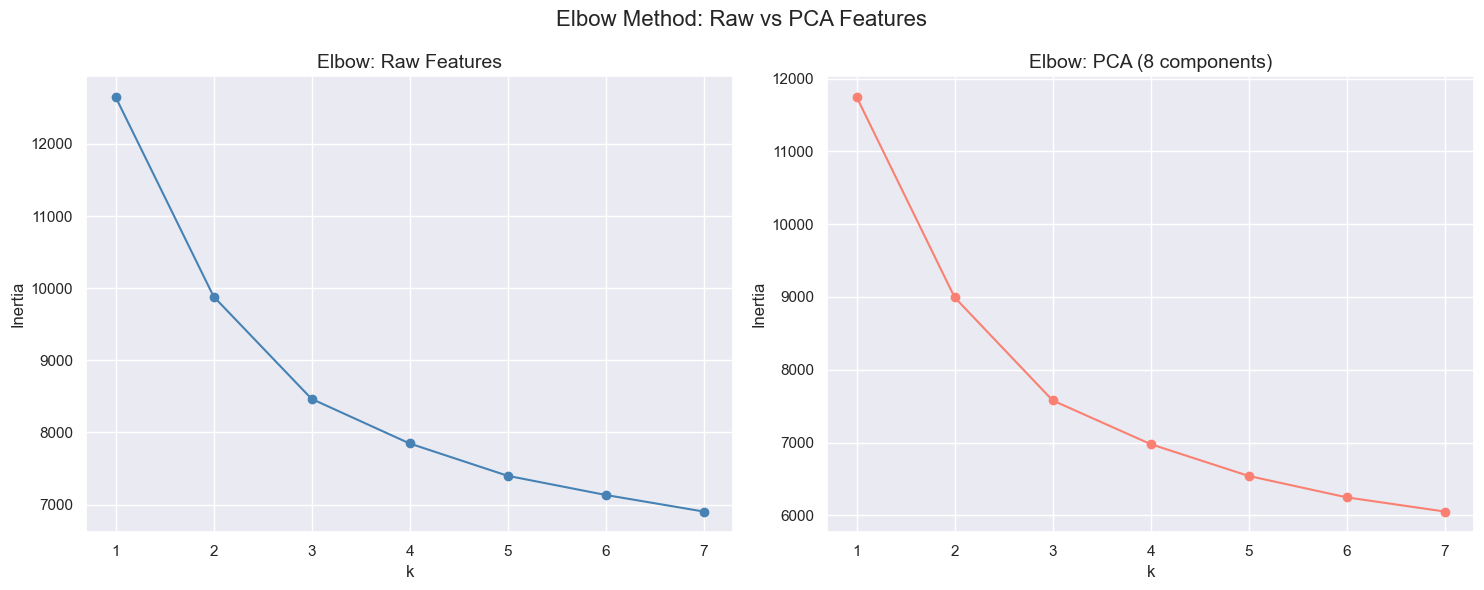

In [7]:
inertias_raw = []
inertias_pca = []
k_range = range(1, 8)

for k in k_range:
    km_raw = KMeans(k=k, max_iters=100)
    km_raw.fit(X_scaled)
    inertias_raw.append(km_raw.inertia_)

    km_pca = KMeans(k=k, max_iters=100)
    km_pca.fit(X_pca)
    inertias_pca.append(km_pca.inertia_)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
ax1.plot(k_range, inertias_raw, marker='o', color='steelblue')
ax1.set_title('Elbow: Raw Features', fontsize=14)
ax1.set_xlabel('k'); ax1.set_ylabel('Inertia')

ax2.plot(k_range, inertias_pca, marker='o', color='salmon')
ax2.set_title(f'Elbow: PCA ({n_components} components)', fontsize=14)
ax2.set_xlabel('k'); ax2.set_ylabel('Inertia')

plt.suptitle('Elbow Method: Raw vs PCA Features', fontsize=16)
plt.tight_layout()
plt.show()

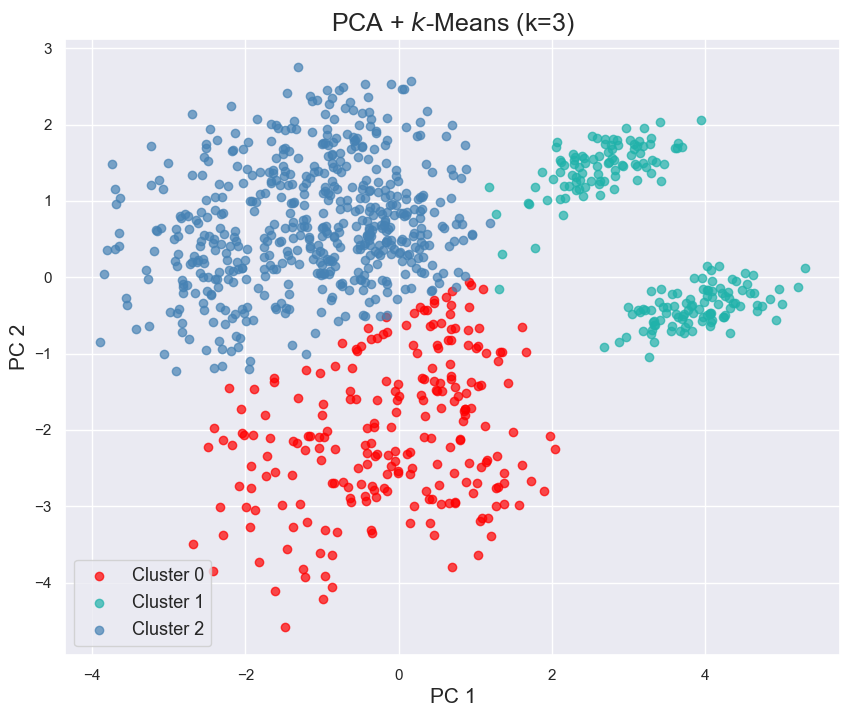

In [8]:
k_best = 3
km = KMeans(k=k_best, max_iters=200)
km.fit(X_pca)

# Project to 2D for visualization
X_2d = PCA(n_components=2).fit_transform(X_scaled)
colors = ['red', 'lightseagreen', 'steelblue', 'magenta', 'orange']

plt.figure(figsize=(10, 8))
for j in range(k_best):
    mask = km.labels_ == j
    plt.scatter(X_2d[mask, 0], X_2d[mask, 1],
                c=colors[j], label=f'Cluster {j}', alpha=0.7)

plt.xlabel('PC 1', fontsize=15)
plt.ylabel('PC 2', fontsize=15)
plt.title(f'PCA + $k$-Means (k={k_best})', fontsize=18)
plt.legend(fontsize=13)
plt.show()

## Comparison: Raw Features vs PCA-Reduced Clustering

In [9]:
from sklearn.metrics import silhouette_score

# Fit k-Means on raw features at the chosen k
km_raw_best = KMeans(k=k_best, max_iters=200)
km_raw_best.fit(X_scaled)

# Fit k-Means on PCA-reduced features
km_pca_best = KMeans(k=k_best, max_iters=200)
km_pca_best.fit(X_pca)

# Compute metrics
# Silhouette on raw features (use raw X_scaled as reference space for both)
sil_raw = silhouette_score(X_scaled, km_raw_best.labels_)
sil_pca = silhouette_score(X_scaled, km_pca_best.labels_)  # labels from PCA clustering

inertia_raw_val = km_raw_best.inertia_
inertia_pca_val = km_pca_best.inertia_  # inertia in PCA space (different scale)

print('=' * 60)
print(f'Comparison at k={k_best}')
print('=' * 60)
print(f'{'Metric':<35} {'Raw k-Means':>12} {'PCA k-Means':>12}')
print('-' * 60)
print(f'{'Inertia (in respective space)':<35} {inertia_raw_val:>12.2f} {inertia_pca_val:>12.2f}')
print(f'{'Silhouette (evaluated on raw X)':<35} {sil_raw:>12.4f} {sil_pca:>12.4f}')
print(f'{'Feature dimensionality':<35} {X_scaled.shape[1]:>12d} {X_pca.shape[1]:>12d}')
print('=' * 60)
print()
print('Note: Inertias are NOT directly comparable (different spaces).')
print('Silhouette score evaluated in raw feature space is the fair comparison.')
if sil_pca > sil_raw:
    print(f'PCA k-Means gives BETTER silhouette (+{sil_pca-sil_raw:.4f}).')
    print('PCA denoised the data and produced tighter clusters.')
else:
    print(f'Raw k-Means gives BETTER silhouette (+{sil_raw-sil_pca:.4f}).')
    print('On this dataset, PCA may have discarded informative variance.')

Comparison at k=3
Metric                               Raw k-Means  PCA k-Means
------------------------------------------------------------
Inertia (in respective space)            8465.02      7578.93
Silhouette (evaluated on raw X)           0.2041       0.2060
Feature dimensionality                        13            8

Note: Inertias are NOT directly comparable (different spaces).
Silhouette score evaluated in raw feature space is the fair comparison.
PCA k-Means gives BETTER silhouette (+0.0019).
PCA denoised the data and produced tighter clusters.


## Interpretation

- PCA denoises the data before clustering, often producing **cleaner cluster boundaries**. the inertia on PCA-reduced data is not directly comparable to raw-feature inertia (different scales), but the **elbow shape** is often more pronounced and the silhouette score in the original feature space is the fair comparison.
- The **silhouette score evaluated on raw features** (even when labels come from PCA clustering) is the correct way to compare: it measures how well-separated the clusters are in the original measurement space.
- For the gym dataset, expected clusters correspond to experience-level archetypes: beginners (shorter sessions, lower caloric burn), intermediate members, and advanced athletes (high intensity, high caloric burn). PCA compresses correlated metrics (BMI + Weight, Calories + Duration) so $k$-Means can find these archetypes without being confused by redundant features.
- This pipeline is standard in practice: StandardScale first, then PCA to 90% variance, then any distance-based algorithm.